# <u>**k**-Nearest Neighbors Regression</u>

## Topics

* [1. Core idea](#idea)
    
* [2. Distance Measures](#distance)
    * [2.1 Manhattan distance](#manhatten)
    * [2.2 Euclidean distance](#euclidean)

* [3. Prediction Methods](#methods)
    * [**3.1 Regression**](#reg)
    * [3.2 Classification](#class)
        * <a href="../../2.Classification/5.k-Nearest Neighbors Classifier/k-Nearest Neighbors Classifier.ipynb">Check out the notebook on **k**-Nearest Neighbors Classifier</a>
    
* [4. Choosing **k** for Regression](#choose_k)
    * [4.1 Small **k**](#small_k)
    * [4.2 Large **k**](#large_k)

* [5. Choosing **k** for Classification](#choose_k2)
    * [4.1 Small **k**](#small_k2)
    * [4.2 Large **k**](#large_k2)

* [6. Model Characteristics](#model)
* [7. Limitations](#limits)
* [8. Feature Scaling & Weights](#scaling)
* [9. Gower distance](#gower)
* [10. Summary](#summary)

* [11. **k**-NN library implementation](#library)

In [ ]:
import numpy as np # for rnadom number, linear algebra and general mathematic operations
import pandas as pd # for creating and working with dataframe
from matplotlib import pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go
from sklearn.neighbors import KNeighborsRegressor # for k-NN Regression
from sklearn.neighbors import NearestNeighbors # only find nearest neighbors
print("Setup complete")

Setup complete


<a class="anchor" id="idea"></a>
# 1. Core idea

- **k**-NN is a simple, non-parametric method used for:
    - Regression (predict numeric values)
    - Classification (predict categories)

- It works by:
    - Finding the **k** closest data points (<u>neighbors</u>) to a new point based on some distance measure
    - Making predictions based on those neighbors

We can define the **k**-neighborhood $N_{\text{k}}(x)$ of $x \in \mathbb{R}^p$ as the subset of data points $x^{(i)}$ that are at least as close to $x$ as its **k**-th closest neighbor $x^{(k)}$: $$N_{\text{k}}(x)=\{x^{(i)} \in \mathbb{R}^p \mid d(x^{(i)},x) \leq d(x^{(k)},x) \}$$

&#128073; It is a local model: Predictions depend only on nearby data.

<p align="center">
<img src="knn.jpeg" width="700"/>
</p>

<a class="anchor" id="distance"></a>
# 2. Distance Measures

To find "nearest" neighbors, distances are computed and for numerical features the **Minkowski** distance of the form 

$$
\lVert x - \tilde{x} \rVert_q = \left(\sum_{j=1}^p \mid x_j - \tilde{x}_j \mid^q \right)^{1/q}, \quad x \in \mathbb{R}^p \text{ and } \tilde{x} \in \mathbb{R}^p
$$

with $p$ being the number of features is often used.

<a class="anchor" id="manhatten"></a>
## 2.1 Manhattan distance 

For $q=1$ we get the Manhattan distance (L1):

$$
d_{\text{manhatten}}(x,\tilde{x})=\lVert x - \tilde{x} \rVert_1 = \left(\sum_{j=1}^p \mid x_j - \tilde{x}_j \mid^1 \right)^{1/1} = \sum_{j=1}^p \mid x_j - \tilde{x}_j \mid
$$

**It is the sum of absolute differences.**


In [246]:
def manhatten(x,x_new):
    x = np.array(x)
    x_new = np.array(x_new)
    return np.sum(np.abs(x-x_new))


<a class="anchor" id="euclidean"></a>
## 2.2 Euclidean distance

For $q=2$ we get the Euclidean distance (L2):

$$
d_{\text{euclidean}}(x,\tilde{x})=\lVert x - \tilde{x} \rVert_2 = \left(\sum_{j=1}^p \mid x_j - \tilde{x}_j \mid^2 \right)^{1/2} = \sqrt{\sum_{j=1}^p (x_j - \tilde{x}_j)^2}
$$

**It is the straight-line distance.**

In [247]:
def euclidean(x,x_new):
    return np.sqrt(np.sum((x-x_new)**2))

<p align="center">
<img src="Minkowski.jpeg" width="600"/>
</p>


&#128680; Important:
- Feature scales matter $\rightarrow$ large-scale features dominate distances
- Solution: Standardization/Normalization

<a class="anchor" id="methods"></a>
# 3. Prediction Methods

<a class="anchor" id="reg"></a>
## 3.1 &#128200; Regression

Predict by averaging the target values $y$ of the **k** neighbors in $N_{\text{k}}(x)$:

- Simple average 
$$
\hat{f}(x) = \frac{1}{\text{k}} \sum_{i:x^{(i)} \in N_{\text{k}}(x)} y^{(i)}
$$


- Weighted average (closer points get more weight) 
$$
\hat{f}(x) = \frac{1}{\sum_{i:x^{(i)} \in N_{\text{k}}(x)} w^{(i)}} \sum_{i:x^{(i)} \in N_{\text{k}}(x)} w^{(i)}y^{(i)}, \quad w^{(i)}=\frac{1}{d(x^{(i)},x)}
$$

<p align="center">
<img src="knn_reg.jpeg" width="700"/>
</p>

k Smallest distances: [(np.float64(0.015056006822324441), 61)]
Nearest Neighbors: [[ 6.01505601 55.6870347 ]]
k Smallest distances: [(np.float64(0.015056006822324441), 61), (np.float64(0.03927562568664733), 46), (np.float64(0.22293180500160403), 95), (np.float64(0.3124387017068333), 80), (np.float64(0.3324259100263811), 58), (np.float64(0.3380504907740933), 6), (np.float64(0.3569962211597968), 79), (np.float64(0.38005610266625656), 29), (np.float64(0.55341463203332), 3), (np.float64(0.5940621960157939), 27)]
Nearest Neighbors: [[ 6.01505601 55.6870347 ]
 [ 6.03927563 49.72752752]
 [ 5.77706819 64.01699464]
 [ 5.6875613  62.05882119]
 [ 6.33242591 55.58316258]
 [ 6.33805049 51.01061   ]
 [ 6.35699622 64.75692027]
 [ 5.6199439  56.63978709]
 [ 5.44658537 60.37504357]
 [ 6.5940622  42.87094521]]


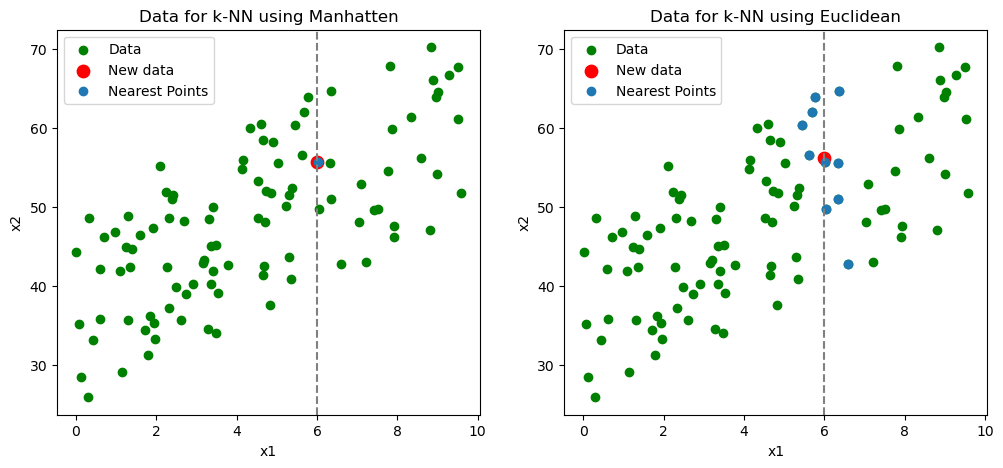

In [248]:
# Generate data
np.random.seed(1400) # for reproducibility
n = 100 # number of data points
X = np.random.uniform(0,10,(n,1)) 
X = np.hstack((X,2.5*X + 2.5*np.random.uniform(10,20,(n,1)))) # matrix of data points


# New data
new_x = np.array([6]) # x2 unknown

# Compute distances with manhatten and k nearest
distances = [(manhatten(x[0],new_x[0]),idx) for idx,x in enumerate(X)]
distances_sorted = sorted(distances, key=lambda x: x[0]) # sort distances
# distances.sort(key=lambda x: x[0]) # sort in place
k = 1 # number of neighbors
nearest_neighbors = distances_sorted[:k]
print("k Smallest distances:",nearest_neighbors)
neighbors_points = [X[idx] for (_, idx) in nearest_neighbors]
neighbors_points = np.array(neighbors_points)
print("Nearest Neighbors:",neighbors_points)

# Predictions
prediction = np.mean(neighbors_points[:,1])


# Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1],color="green",label="Data")
plt.scatter(new_x[0],prediction,s=80,color="red",label="New data")
plt.axvline(new_x[0],linestyle="--", color="gray")
plt.scatter(neighbors_points[:,0],neighbors_points[:,1], label="Nearest Points")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Data for k-NN using Manhatten")
plt.legend()


# New data
new_x = np.array([6]) # x2 unknown

# Compute distances with euclidean and k nearest
distances = [(euclidean(x[0],new_x[0]),idx) for idx,x in enumerate(X)]
distances_sorted = sorted(distances, key=lambda x: x[0]) # sort distances
# distances.sort(key=lambda x: x[0]) # sort in place
k = 10 # number of neighbors
nearest_neighbors = distances_sorted[:k]
print("k Smallest distances:",nearest_neighbors)
neighbors_points = [X[idx] for (_, idx) in nearest_neighbors]
neighbors_points = np.array(neighbors_points)
print("Nearest Neighbors:",neighbors_points)

# Predictions
prediction = np.mean(neighbors_points[:,1])


# Plot
plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],color="green",label="Data")
plt.scatter(new_x[0],prediction,s=80,color="red",label="New data")
plt.axvline(new_x[0],linestyle="--", color="gray")
plt.scatter(neighbors_points[:,0],neighbors_points[:,1], label="Nearest Points")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Data for k-NN using Euclidean")
plt.legend()


plt.show()

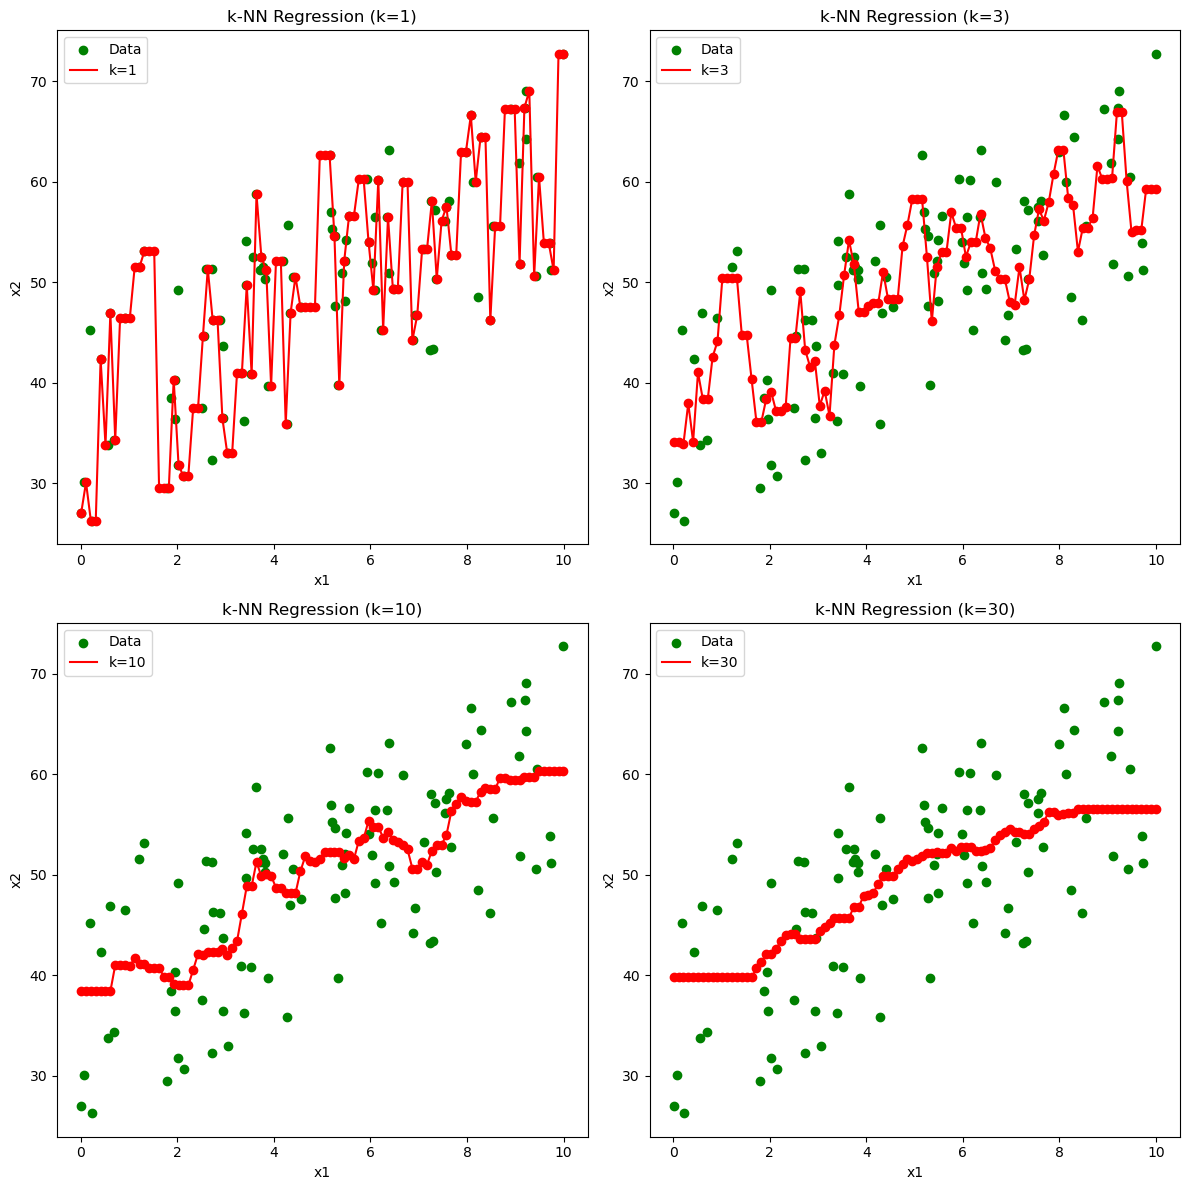

In [249]:
# Generate data
np.random.seed(1645) # for reproducibility
n = 100 # sample size
X = np.random.uniform(0,10,(n,1)) 
X = np.hstack((X,2.5*X + 2.5*np.random.uniform(10,20,(n,1)))) # matrix of data points

def k_NN_2d(X, k, distance_measure):
    new_xs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100) # x2 unknown
    predictions = []

    for new_x in new_xs:
        distances = [(distance_measure(x[0], new_x), idx) for idx, x in enumerate(X)]
        distances.sort(key=lambda x: x[0])
        nearest_neighbors = distances[:k]

        neighbors_points = np.array([X[idx] for (_, idx) in nearest_neighbors])
        predictions.append(np.mean(neighbors_points[:,1]))

    return new_xs, np.array(predictions)


ks = [1, 3, 10, 30]

plt.figure(figsize=(12,12))

for i, k in enumerate(ks):
    plt.subplot(2,2,i+1)

    new_xs, predictions = k_NN_2d(X, k, manhatten)

    plt.scatter(X[:,0], X[:,1], color="green", label="Data")
    plt.scatter(new_xs, predictions, color="red")
    plt.plot(new_xs, predictions, color="red", label=f"k={k}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"k-NN Regression (k={k})")
    plt.legend()

plt.tight_layout()
plt.show()

In [250]:
np.random.seed(1724)
n = 100 # number of data points
X = np.random.uniform(0,10,(n,2))
X = np.column_stack([X,2*X[:,1] + np.random.normal(0,6,n)]) # 3 features

new_data = np.array([4,2])

distances = [[euclidean(x[0:2],new_data),idx] for idx, x in enumerate(X)]
distances.sort(key=lambda x: x[0])
k = 3
k_shortest = distances[:k]
neighbors = np.array([X[idx] for (_, idx) in k_shortest])
prediction = np.mean(neighbors[:,2])



fig=px.scatter_3d(x=X[:,0],y=X[:,1],z=X[:,2],labels={"x":"x1","y":"x2","z":"x3"},title="k-NN with euclidean")

# new point with unknown target x3 (x3=0)
fig.add_trace(go.Scatter3d(
    x=[new_data[0]],
    y=[new_data[1]],
    z=[0],
    mode='markers',
    marker=dict(size=10, color='orange'),
    name="New data (unknown x3)"
))

# Predicted point
fig.add_trace(go.Scatter3d(
    x=[new_data[0]],
    y=[new_data[1]],
    z=[prediction],
    mode='markers',
    marker=dict(size=10, color='red'),
    name="Prediction"
))


# Nearest neighbors
fig.add_trace(go.Scatter3d(
    x=neighbors[:,0],
    y=neighbors[:,1],
    z=neighbors[:,2],
    mode='markers',
    marker=dict(size=6, color='blue'),
    name="Nearest neighbors"
))

fig.show()

<a class="anchor" id="class"></a>
## 3.2 &#128278; Classification

* Predict by majority vote among neighbors for classification in $g$ groups
$$
\hat{h}(x)=\underset{l \in \{1,2,\ldots,g\}}{\arg\max} \sum_{i:x^{(i)} \in N_{\text{k}}(x)} \mathbb{I}(y^{(i)} = l)
$$


* Estimate posterior probabilities as proportion of neighbors in each class
$$
\hat{\pi}_l(x)=\frac{1}{\text{k}} \sum_{i:x^{(i)} \in N_{\text{k}}(x)} \mathbb{I}(y^{(i)} = l)
$$

<p align="center">
<img src="knn_class.jpeg" width="700"/>
</p>

<a href="../../2.Classification/5.k-Nearest Neighbors Classifier/k-Nearest Neighbors Classifier.ipynb">Check out the notebook on **k**-Nearest Neighbors Classifier for code.</a>

<a class="anchor" id="choose_k"></a>
# 4. Choosing **k** for Regression

<a class="anchor" id="small_k"></a>
## 4.1 Small **k** (e.g., 1-3)
**Low bias but high variance**:
- Low bias: Can fit complex patterns
- High variance: Predictions vary a lot since they rely on very few neighbors
- Predictions are very sensitive to noise
- The regression curve becomes wiggly / highly flexible
- In extreme case **k**=1: Prediction is just the value of the nearest neighbor $\rightarrow$ can be very noisy.
- Small **k** $\rightarrow$ "listen to closest voices" $\rightarrow$ noisy but detailed

<a class="anchor" id="large_k"></a>
## 4.2 Large **k**
**Low variance but high bias**:
- High bias: Misses local structure
- Low variance: Predictions vary less since they rely on many neighbors
- The model averages over many points
- In extreme case **k**=n: Predict the global mean of all targets $\rightarrow$ no local adaptation at all.
- Predictions become very smooth

- Large **k** $\rightarrow$ "listen to the crowd" $\rightarrow$ smooth but less precise

&#128073; Trade-off: Bias vs Variance

<p align="center">
<img src="bias_variance_reg.jpeg" width="550"/>
</p>



<a class="anchor" id="choose_k2"></a>
# 5. Choosing **k** for Classification

<a class="anchor" id="small_k2"></a>
## 5.1 Small **k** (e.g., 1-3)

**Low bias but high variance**:
- Low bias: New data points often get classified correctly
- High variance: New data points get classified based on very few neighbors resulting in often different classes for new data points in close proximity
- Sensitive to noise/outliers: Outliers can influence class of new data points more easily
- Very flexible and "wiggly" decision boundaries




<a class="anchor" id="large_k2"></a>
## 5.2 Large **k**
**Low variance but high bias**
- High bias: New data points get missclassified more often
- Low variance: New data points get classified based on many neighbors resulting in predictions based on the dominant class in that proximity (may miss local patterns)
- Less sensitive no noise/outliers: Outlier now carry weaker influence since they are in the minority
- More stable and "smooth" decision boundaries


&#128073; Trade-off: Bias vs Variance

<p align="center">
<img src="bias_variance.jpeg" width="550"/>
</p>

<a class="anchor" id="model"></a>
# 6. Model Characteristics

Lazy learning:
- No real training phase
- Stores all training data

Non-parametric:
- Parameters of **k**-NN are the training data
- Model complexity grows with data

No assumptions:
- **k**-NN is not based on distributions 
- Can model very complex patterns 

<a class="anchor" id="limits"></a>
# 7. Limitations

* Sensitive to:
    - Noisy data
    - Irrelevant features/ High dimensional data points
    - Different feature scales
    - Class imbalance for **k**-NN for Classifier
        - Example: If 90% of data is class A $\rightarrow$ prediction biased toward A
        - Fix: weighted voting or resampling

* Computationally expensive for large datasets

* Requires careful choice of **k** and distance metric  $d(x,\tilde{x})$

<a class="anchor" id="scaling"></a>
# 8. Feature scaling & Weights

Standardization
- Features should be standardized or normalized
- Example $(x_1,x_2)$: If $x_1 \in \underbrace{\{0,1000\}}_{\text{large scale}}$ and $x_2 \in  \underbrace{\{0,10\}}_{\text{small scale}}$ then most distance metrics would place higher importance on $x_1$.


Importance
- Assign weights to features if some are more important (i.e. weighted euclidean distance)
$$
d_{\text{euclidean}}^{\text{weighted}}(x,\tilde{x})=\sqrt{\sum_{j=1}^p w_j(x_j - \tilde{x}_j)^2}
$$

Prediction: 8.777040259271562


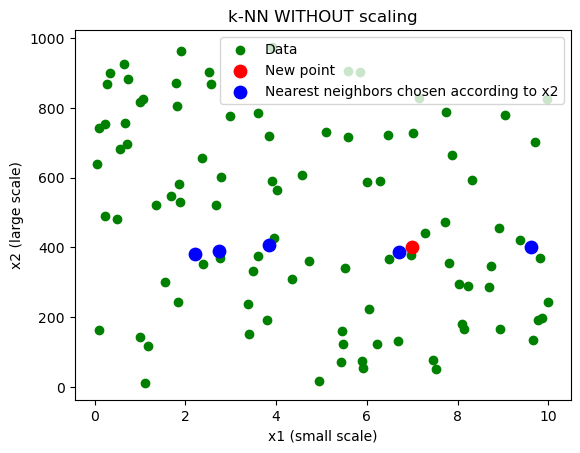

In [251]:
np.random.seed(1758)
n = 100 # sample size
x1 = np.random.uniform(0, 10, n) # Feature 1 (small scale)
x2 = np.random.uniform(0, 1000, n) # Feature 2 (large scale)
x3 = np.random.uniform(0, 20, n) # Target (similar scale to Feature 1)

X = np.column_stack((x1, x2, x3))

def knn_predict(X, new_point, k=5):
    distances = [(euclidean(x[:2], new_point), idx) for idx, x in enumerate(X)]
    distances.sort(key=lambda x: x[0])
    
    neighbors = np.array([X[idx] for (_, idx) in distances[:k]])

    return np.mean(neighbors[:,2]), neighbors

new_point = np.array([7, 400]) # new point

prediction, neighbors = knn_predict(X, new_point, k=5)
print("Prediction:", prediction)

plt.scatter(X[:,0], X[:,1], color="green", label="Data")
plt.scatter(new_point[0], new_point[1], color="red", s=80, label="New point")

# highlight neighbors
plt.scatter(neighbors[:,0], neighbors[:,1],
            color="blue", s=80, label="Nearest neighbors chosen according to x2")

plt.xlabel("x1 (small scale)")
plt.ylabel("x2 (large scale)")
plt.title("k-NN WITHOUT scaling")
plt.legend()
plt.show()

Prediction (scaled): 5.688193919656841


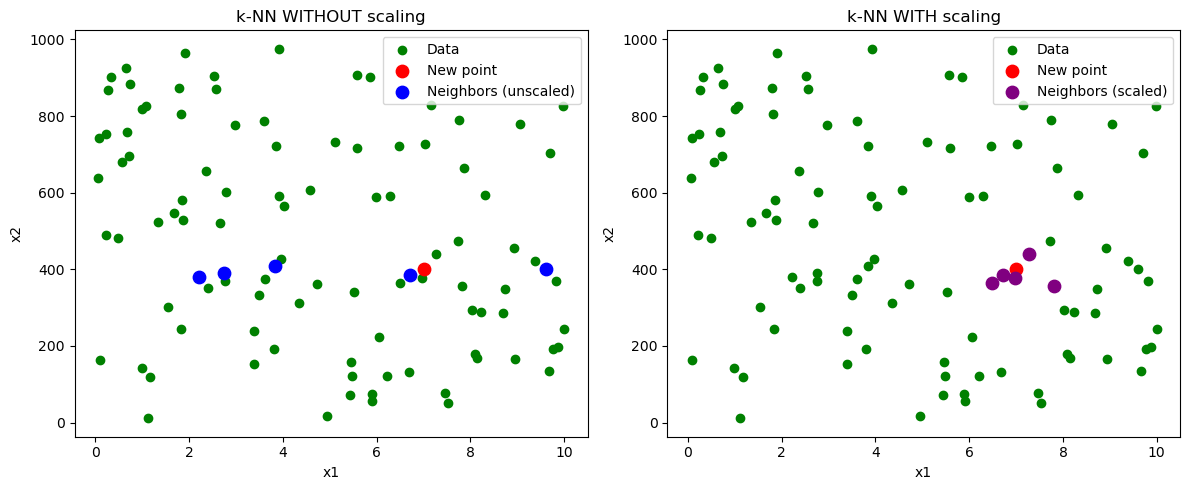

In [252]:
def standard(X):
    """
    Standardizes features with mean and standard deviation
    Input:
        - array X of shape (n,p) with n=number of observations and p=number of features (no intercept column)
    Output:
        - array X with standardized values per column
    """
    feature_means = np.mean(X, axis=0) # mean per column
    feature_std = np.std(X, axis=0) # variance per column
    feature_std[feature_std == 0] = 1 # avoid division by 0
    return (X - feature_means) / feature_std

# Standardize only the features not the target
X_features = X[:, :2] # x1, x2
y = X[:, 2] # target

X_scaled = standard(X_features)

# also scale the new point
feature_means = np.mean(X_features, axis=0)
feature_std = np.std(X_features, axis=0)
feature_std[feature_std == 0] = 1

new_point_scaled = (new_point - feature_means) / feature_std

def knn_predict_scaled(X_scaled, y, new_point_scaled, k=5):
    distances = [(euclidean(x, new_point_scaled), idx) for idx, x in enumerate(X_scaled)]
    distances.sort(key=lambda x: x[0])
    
    neighbors_idx = [idx for (_, idx) in distances[:k]]
    neighbors = X[neighbors_idx]  # original points (for plotting)

    prediction = np.mean(y[neighbors_idx])
    return prediction, neighbors

prediction_scaled, neighbors_scaled = knn_predict_scaled(X_scaled, y, new_point_scaled, k=5)

print("Prediction (scaled):", prediction_scaled)

plt.figure(figsize=(12,5))

# Before scaling 
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], color="green", label="Data")
plt.scatter(new_point[0], new_point[1], color="red", s=80, label="New point")
plt.scatter(neighbors[:,0], neighbors[:,1],
            color="blue", s=80, label="Neighbors (unscaled)")
plt.title("k-NN WITHOUT scaling")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

# After scaling
plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], color="green", label="Data")
plt.scatter(new_point[0], new_point[1], color="red", s=80, label="New point")
plt.scatter(neighbors_scaled[:,0], neighbors_scaled[:,1],
            color="purple", s=80, label="Neighbors (scaled)")
plt.title("k-NN WITH scaling")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

plt.tight_layout()
plt.show()

```python
from sklearn.preprocessing import StandardScaler # used to standardize features by removing the mean and scaling to unit variance

X = np.array([[1, 2], [3, 4], [5, 6]]) # data matrix of shape (n_samples, n_features)
# array([[1, 2],
#       [3, 4],
#       [5, 6]])

scaler = StandardScaler(copy=True,with_mean=True,with_std=True) # create a sklearn.preprocessing._data.StandardScaler object
# with_mean -> Whether centering is applied
# with_std -> Whether scaling is applied
# copy -> Copy or in-place transform

scaler.fit(X) # Standarscaler learns the statistics of X and computes mean and variance/std of each feature

scaler.mean_ # returns an arry of shape (n_features,) with the mean of each feature (only available if with_mean=True)
scaler.var_ # returns an arry of shape (n_features,) with the variance of each feature (Used to compute the standard deviation)
scaler.scale_ # returns an arry of shape (n_features,) with the standard deviation (only available if with_std=True and if variance is zero then scale is set to 1 to avoid division by zero)
scale.n_features_in_ # number of features seen during fit()
scale.feature_names_in_ # returns an arry of shape (n_features,) with names of features (only if input has column names, e.g. pandas DataFrame)
scale.n_samples_seen_ # Number of samples processed
X_scaled = scaler.transform(X) # applies standardization: X_scaled = (X - mean_) / scale_
X_scaled = scaler.fit_transform(X) # shortcut
```

<a class="anchor" id="gower"></a>
# 9. Gower distance

Used when data includes:
- Mixed types (numerical + categorical)
- Missing values

Key ideas:
- Combines feature-wise distances
- Handles:
    - categorical (match/mismatch)
    - numerical (scaled differences)
- Ignores missing values in comparisons

$$
d_{\text{gower}}(x,\tilde{x}) = \frac{\sum_{j=1}^p \delta_{x_j,\tilde{x}_j} \cdot d_{\text{gower}}(x_j,\tilde{x}_j)}{\sum_{j=1}^p \delta_{x_j,\tilde{x}_j} }
$$

$$
\delta_{x_j,\tilde{x}_j}=
\begin{cases}
0 &, \text{if } j\text{-th feature is missing in at least one observation} \\
& \text{ or if feature is asymmetric binary and both values are zero} 
\\ 
1 &, \text{otherwise} \\
\end{cases}
$$

Features are asymmetric binary if "1" is more important than "0". 

For categoricals:
$$
d_{\text{gower}}(x_j,\tilde{x}_j)=
\begin{cases}
0 &, \text{ if  both values are equal}
\\ 
1 &, \text{otherwise} \\
\end{cases}
$$


For integers and numericals:
$$
d_{\text{gower}}(x_j,\tilde{x}_j)= \text{ absolute difference}
$$

**Example:**

$$
\begin{array}{c|c|c}
 & \text{sex} & \text{salary} \\
\hline
1 & m & 2340 \\
2 & w & 2100 \\
3 & \text{NA} & 2680 \\
\end{array}
$$

$$
d_{\text{gower}}(x^{(1)}, x^{(2)}) =
\frac{1 \cdot 1 + 1 \cdot \frac{\mid 2340 - 2100 \mid}{\mid 2680 - 2100 \mid}}{1 + 1}=\frac{1 + \frac{240}{580}}{2}= 0.707
$$

$$
d_{\text{gower}}(x^{(1)}, x^{(3)}) =\frac{0 \cdot 1 + 1 \cdot \frac{\mid 2340 - 2680 \mid}{\mid 2680 - 2100 \mid}}{0 + 1}=\frac{\frac{340}{580}}{1}=0.586
$$

$$
d_{\text{gower}}(x^{(2)}, x^{(3)}) =\frac{0 \cdot 1 + 1 \cdot \frac{\mid 2100 - 2680 \mid}{\mid 2680 - 2100 \mid}}{0 + 1}=\frac{\frac{580}{580}}{1}=1
$$

<a class="anchor" id="summary"></a>
# 10. Summary

* **k**-NN is simple but powerful
* Works well for nonlinear problems
* Performance depends heavily on:
    * choice of **k**
    * distance metric
    * feature preprocessing

<a class="anchor" id="library"></a>
# 11. **k**-NN library implementation

```python
# 1. k-NN (scikit-learn)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Regression 
model1_reg = KNeighborsRegressor(
    n_neighbors=5,
    weights="uniform",
    algorithm="auto",
    p=2,
    metric="minkowski"
)

model1_reg.fit(X, y)

model1_reg.predict(X)       # predicted values
model1_reg.score(X, y)      # R^2 score

# Classification 
model1 = KNeighborsClassifier(
    n_neighbors=5, # k (number of neighbors)
    weights="uniform", # "uniform" or "distance"
    algorithm="auto", # "auto", "ball_tree", "kd_tree", "brute"
    leaf_size=30, # tree parameter (for ball_tree / kd_tree)
    p=2, # distance metric power (p=2 -> Euclidean)
    metric="minkowski", # distance metric
    n_jobs=None # parallel jobs (-1 = use all cores)
)

model1.fit(X, y) # store training data (lazy learning)

model1.predict(X) # predicted class labels
model1.predict_proba(X) # class probabilities
model1.score(X, y) # accuracy
model1.kneighbors(X) # distances + indices of nearest neighbors


# 2. k-NN with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": range(1, 21), # candidate k values
    "weights": ["uniform", "distance"],
    "p": [1, 2] # Manhattan vs Euclidean
}

model2 = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5, # k-fold CV
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_ # best hyperparameters
model2.best_score_ # best CV score
model2.best_estimator_


# 3. Distance-based usage (manual neighbor queries)
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(
    n_neighbors=5,
    algorithm="auto",
    metric="minkowski",
    p=2
)

nn.fit(X)

distances, indices = nn.kneighbors(X) # nearest neighbors


# 4. k-NN with precomputed distance matrix
from sklearn.neighbors import KNeighborsClassifier

model4 = KNeighborsClassifier(
    n_neighbors=5,
    metric="precomputed" # use custom distance matrix
)

model4.fit(D_train, y) # D_train = distance matrix
model4.predict(D_test)


# 5. Using FAISS (fast large-scale k-NN, GPU optional)
import faiss
import numpy as np

X_np = np.array(X).astype("float32")

index = faiss.IndexFlatL2(X_np.shape[1]) # L2 distance
index.add(X_np) # add dataset

k = 5
distances, indices = index.search(X_np, k) # k-NN search


# 6. Using Annoy (approximate nearest neighbors)
from annoy import AnnoyIndex

f = X.shape[1]  # number of features
index = AnnoyIndex(f, "euclidean")

for i, v in enumerate(X.values):
    index.add_item(i, v)

index.build(10) # number of trees

indices = index.get_nns_by_vector(X.iloc[0].values, 5)
```

In [256]:
# Toy dataset
X = np.array([[25], [30], [35], [40], [45]])  # feature: age
y = np.array([2000, 2500, 3000, 3500, 4000])  # target: salary

# k-NN Regression using KNeighborsRegressor
model = KNeighborsRegressor(
    n_neighbors=2,     # k = 2 neighbors
    weights="uniform", # average of neighbors
    metric="minkowski",
    p=2                # Euclidean distance
)

model.fit(X, y)

# Predict salary for a new person aged 33
X_new = np.array([[33]])
y_pred = model.predict(X_new)

print("Predicted salary:", y_pred)



# Inspect nearest neighbors directly

nn = NearestNeighbors(
    n_neighbors=2,
    metric="minkowski",
    p=2
)

nn.fit(X)

distances, indices = nn.kneighbors(X_new)

print("Neighbor indices:", indices)
print("Neighbor distances:", distances)

# Show actual neighbor values
print("Neighbor ages:", X[indices[0]])
print("Neighbor salaries:", y[indices[0]])


# Using distance-weighted k-NN
model_weighted = KNeighborsRegressor(
    n_neighbors=2,
    weights="distance"  # closer neighbors have more influence
)

model_weighted.fit(X, y)

y_pred_weighted = model_weighted.predict(X_new)

print("Distance-weighted prediction:", y_pred_weighted)

Predicted salary: [2750.]
Neighbor indices: [[2 1]]
Neighbor distances: [[2. 3.]]
Neighbor ages: [[35]
 [30]]
Neighbor salaries: [3000 2500]
Distance-weighted prediction: [2800.]
